In [1]:
from modpath import modify_path

modify_path()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dython.nominal import associations

from src import db_config, model_config, pipelines

In [ ]:
cleaning_stage = db_config.ProjectStage.CLEANING
data, test = pipelines.load_data(
    train_table=db_config.build_table_name(
        cleaning_stage, db_config.DatasetSplit.TRAIN
    ),
    test_table=db_config.build_table_name(cleaning_stage, db_config.DatasetSplit.TEST),
)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   id                      103904 non-null  int64 
 1   gender                  103904 non-null  object
 2   is_loyal_customer       103904 non-null  int64 
 3   age                     103904 non-null  int64 
 4   is_personal_travel      103904 non-null  int64 
 5   class                   103904 non-null  object
 6   flight_distance         103904 non-null  int64 
 7   wifi_service            103904 non-null  int64 
 8   convenient_time         103904 non-null  int64 
 9   online_booking_ease     103904 non-null  int64 
 10  gate_location           103904 non-null  int64 
 11  food_drink              103904 non-null  int64 
 12  online_boarding         103904 non-null  int64 
 13  seat_comfort            103904 non-null  int64 
 14  inflight_entertainment  103904 non-n

In [5]:
(data['arrival_delay'] % 1 != 0).sum()

np.int64(0)

In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      25976 non-null  int64 
 1   gender                  25976 non-null  object
 2   is_loyal_customer       25976 non-null  int64 
 3   age                     25976 non-null  int64 
 4   is_personal_travel      25976 non-null  int64 
 5   class                   25976 non-null  object
 6   flight_distance         25976 non-null  int64 
 7   wifi_service            25976 non-null  int64 
 8   convenient_time         25976 non-null  int64 
 9   online_booking_ease     25976 non-null  int64 
 10  gate_location           25976 non-null  int64 
 11  food_drink              25976 non-null  int64 
 12  online_boarding         25976 non-null  int64 
 13  seat_comfort            25976 non-null  int64 
 14  inflight_entertainment  25976 non-null  int64 
 15  on

In [7]:
# Check for missing values
for d in [data, test]:
    for col in d.columns:
        if d[col].isna().sum() > 0:
            print(f"{col} has {d[col].isna().sum()} missing values")

    print()

## Arrival Delays

Some values are missing from the arrival delays column.

In [ ]:
# Use the raw data
raw_stage = db_config.ProjectStage.RAW
data_raw, test_raw = pipelines.load_data(
    train_table=db_config.build_table_name(raw_stage, db_config.DatasetSplit.TRAIN),
    test_table=db_config.build_table_name(raw_stage, db_config.DatasetSplit.TEST),
)

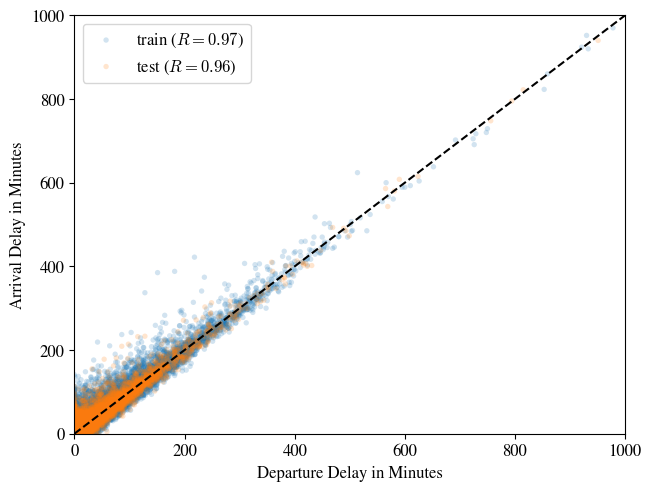

In [9]:
fig, ax = plt.subplots(constrained_layout=True)
for d, l in zip([data_raw, test_raw], ['train', 'test']):
    correlation = d['Departure Delay in Minutes'].corr(d['Arrival Delay in Minutes'])
    sns.scatterplot(
        data=d,
        x='Departure Delay in Minutes',
        y='Arrival Delay in Minutes',
        s=15,
        edgecolor='none',
        alpha=0.2,
        label=fr"{l} ($R = {correlation:.2f}$)",
    )
ax.plot([0, 1], [0, 1], transform=ax.transAxes, color='k', linestyle='--')
ax.set(xlim=(0, 1000), ylim=(0, 1000))
plt.show()

The arrival delay times and departure delay times are highly correlated. Though air travel time can vary to some extent, it's reasonable to expect these delays to be similar.

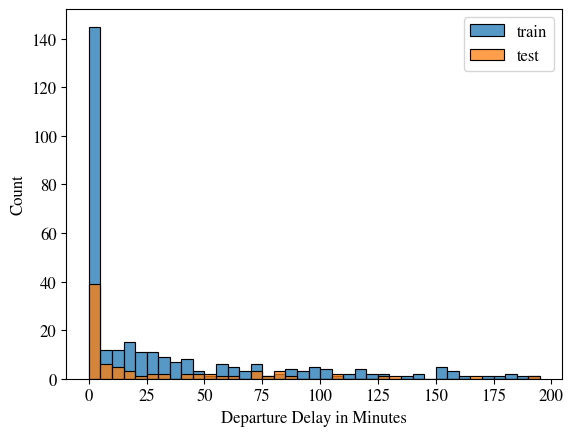

In [10]:
for d, l in zip([data_raw, test_raw], ['train', 'test']):
    sns.histplot(
        data=d[d['Arrival Delay in Minutes'].isna()],
        x='Departure Delay in Minutes',
        bins=np.arange(0, 200, 5),
        label=l,
    )
plt.legend()
plt.show()

In [11]:
lam = lambda x: print(
    f"{(x.loc[x['Arrival Delay in Minutes'].isna(), 'Departure Delay in Minutes'] == 0).sum():>3}"
    f" of {x['Arrival Delay in Minutes'].isna().sum():>3}"
    f" missing arrivals have departure delays of 0 minutes."
)
lam(data_raw)
lam(test_raw)

116 of 310 missing arrivals have departure delays of 0 minutes.
 31 of  83 missing arrivals have departure delays of 0 minutes.


Most of the delay times are 5 minutes or less. However, it seems sensible that the arrival and departure times should be highly correlated (and they are), so we'll impute the missing arrival times using the departure times.

## EDA Continued

In [12]:
# Check if all ids are unique
print(data['id'].nunique() == len(data), test['id'].nunique() == len(test))

True True


All IDs are unique so we will assume all the passengers are unique.

In [13]:
# Check options for non-numeric columns
for d in [data, test]:
    for col in d.columns:
        if pd.api.types.is_string_dtype(d[col]):
            print(f"{col} unique values: {list(d[col].unique())}")
    print()

gender unique values: ['Male', 'Female']
class unique values: ['Eco', 'Eco Plus', 'Business']

gender unique values: ['Female', 'Male']
class unique values: ['Eco', 'Eco Plus', 'Business']



Convert categorical columns into category dtypes

In [14]:
def convert_to_categorical(data: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """
    Convert the specified columns to categorical dtype.

    """
    df = data.copy()
    for col in cols:
        df[col] = df[col].astype('category')

    return df

In [ ]:
df = convert_to_categorical(data, cols=model_config.CATEGORICAL_COLS)
df_test = convert_to_categorical(test, cols=model_config.CATEGORICAL_COLS)

In [ ]:
for d in [df, df_test]:
    satisfied_frac = d[model_config.TARGET].sum() / len(d)
    print(f"Fraction of satisfied customers: {satisfied_frac:.2%}")
    print(d[model_config.TARGET].value_counts())
    print()

Fraction of satisfied customers: 43.33%
satisfied
0    58879
1    45025
Name: count, dtype: int64

Fraction of satisfied customers: 43.90%
satisfied
0    14573
1    11403
Name: count, dtype: int64



## Visualizations

Plot histograms of numeric columns separated by satisfied and non-satisfied customers.

### Numeric Features

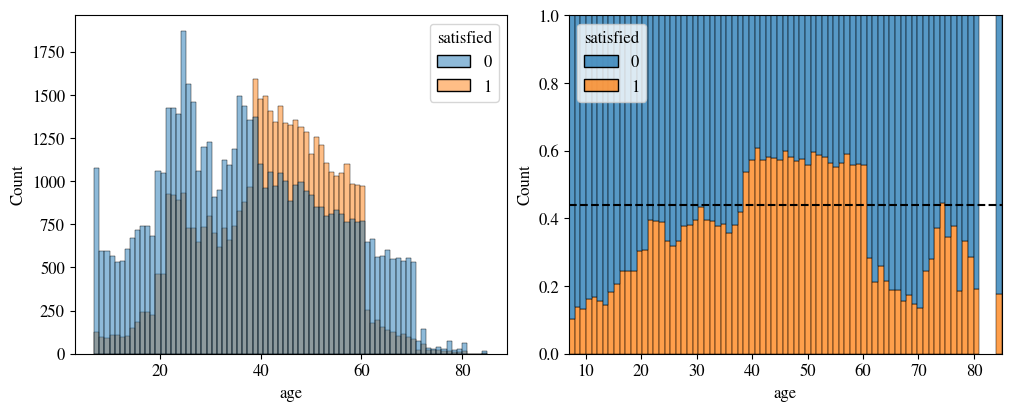

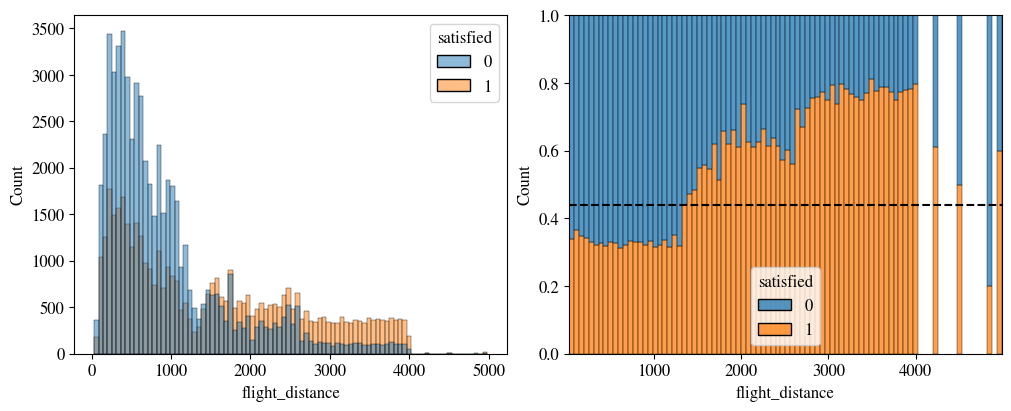

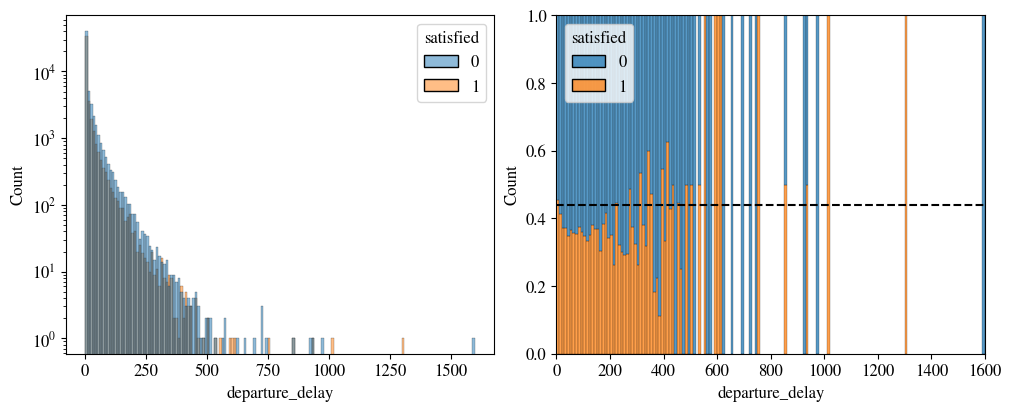

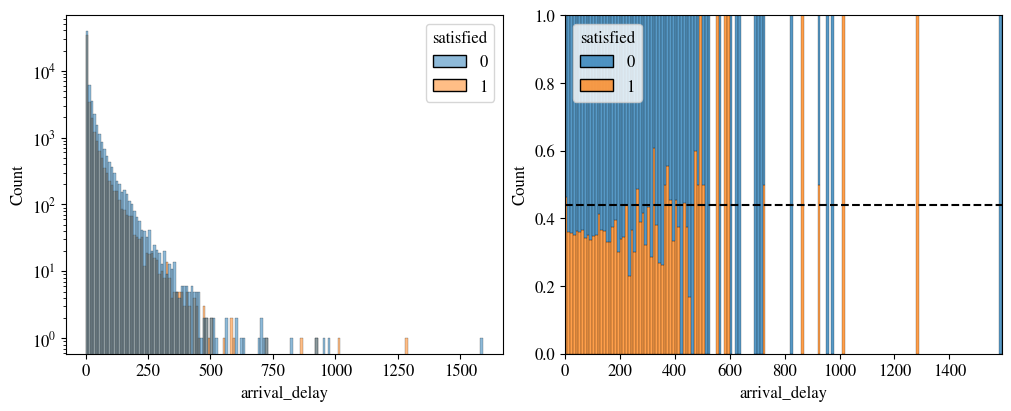

In [ ]:
satisfied = df[model_config.TARGET]

for i, col in enumerate(model_config.NUMERIC_COLS):
    fig, ax = plt.subplots(figsize=(10, 4), ncols=2, constrained_layout=True)
    if i > 1:
        bins = np.arange(0, df[col].max() + 10, 10)
        sns.histplot(x=df[col], bins=bins, hue=satisfied, ax=ax[0])
        sns.histplot(x=df[col], bins=bins, multiple='fill', hue=satisfied, ax=ax[1])
        ax[0].set(yscale='log')
        ax[1].axhline(y=satisfied_frac, color='k', linestyle='--')
    else:
        sns.histplot(data=df, x=col, hue=model_config.TARGET, ax=ax[0])
        sns.histplot(data=df, x=col, multiple='fill', hue=model_config.TARGET, ax=ax[1])
        ax[1].axhline(y=satisfied_frac, color='k', linestyle='--')

    plt.show()

Observations:
1. Satisfaction rate is generally higher for passengers between the ages of 40 to 60 years old.
    - This may be the result of other factors. Passengers in this age range may more likely be flying in business class or more likely flying for business reasons. Flying in business class would probably increase satisfaction, and flying at a company's expense rather than their own may also increase satisfaction.
2. Satisfaction rate is generally higher for passengers taking longer flights.
    - Passengers may book more favorable flights when they know it's going to be a longer journey.
    - Satisfaction may be affected by the passengers' general feelings of the trips they are taking. Longer trips may correspond to going to a new, faraway location, perhaps for a vacation, which makes them feel more positively about their flight experience.
3. Satisfaction rate does not appear to depend much on how long departure or arrival delays are.
    - Satisfaction rate is notably higher when there are no-to-short (< 10 mins) delays and drops to a somewhat consistent level when there are longer delays.

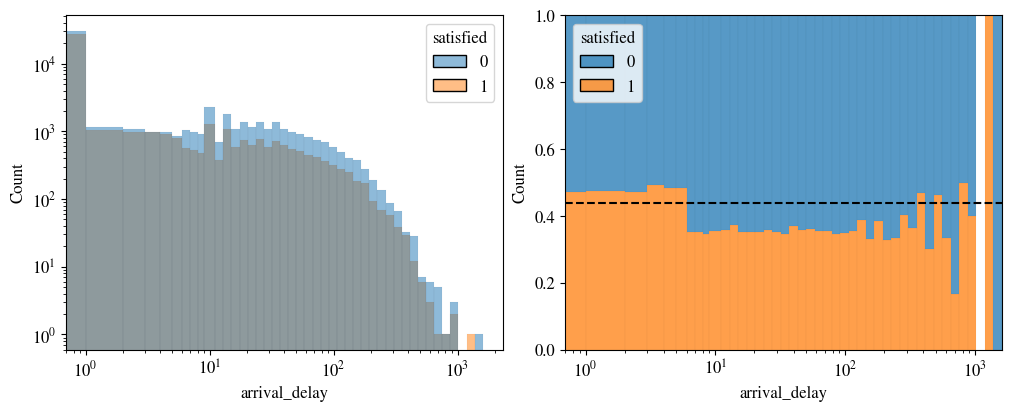

In [18]:
cts, bins = np.histogram(
    df['arrival_delay'].dropna(), bins=np.logspace(0, np.log10(1600), 50)
)
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] + list(bins[bins > 11])

fig, ax = plt.subplots(figsize=(10, 4), ncols=2, constrained_layout=True)
ret = sns.histplot(x=df['arrival_delay'], bins=bins, hue=satisfied, ax=ax[0])
sns.histplot(
    x=df['arrival_delay'],
    bins=bins,
    multiple='fill',
    hue=satisfied,
    ax=ax[1],
)
ax[0].set(yscale='log', xscale='log')
ax[1].set(xscale='log')
ax[1].axhline(y=satisfied_frac, color='k', linestyle='--')
plt.show()

There's a dropoff in satisfaction rate once delays exceed about 6 minutes.

### Rating Features

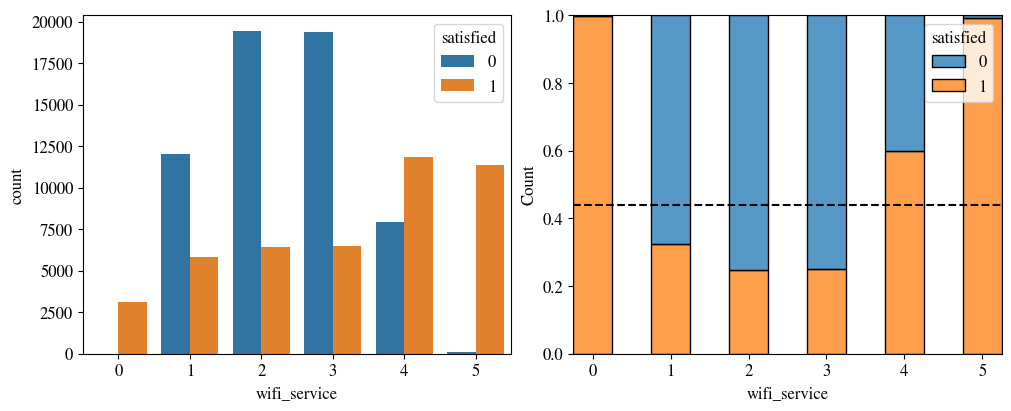

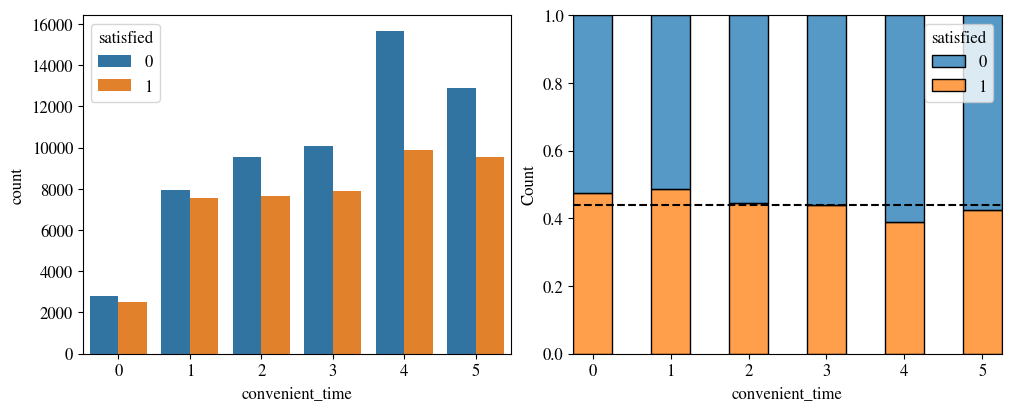

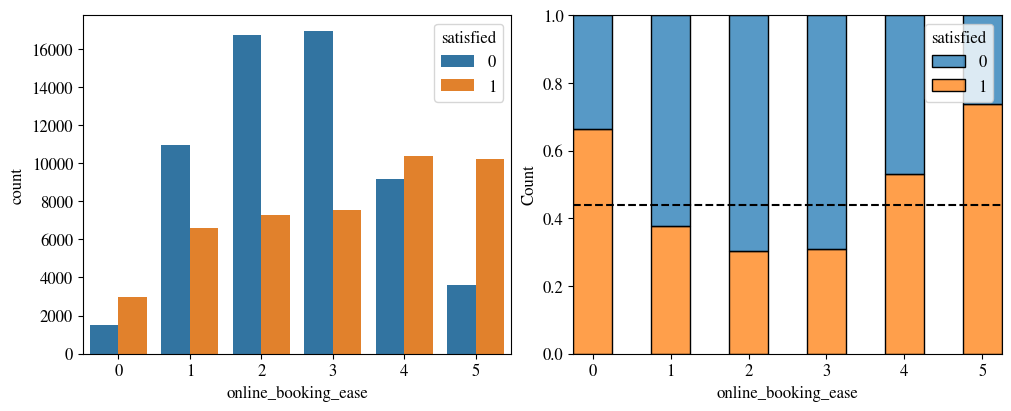

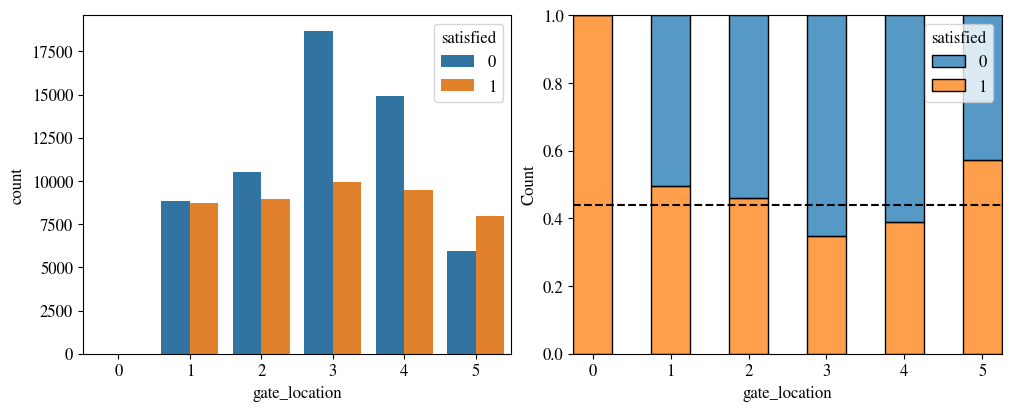

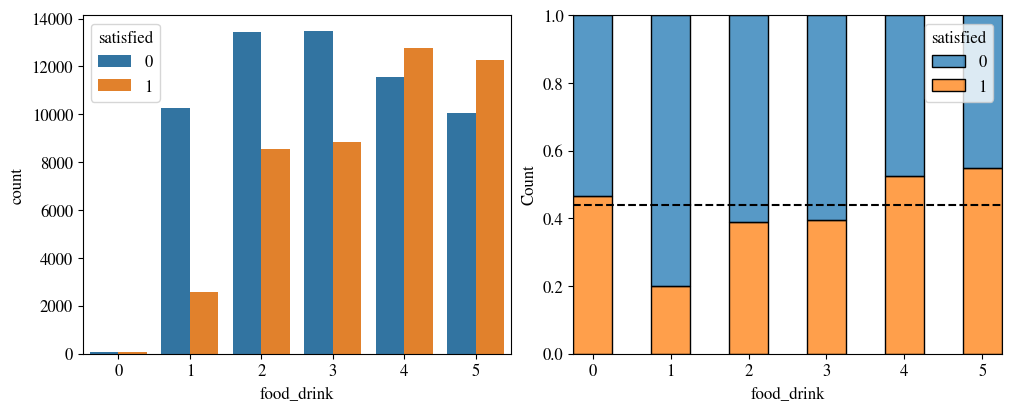

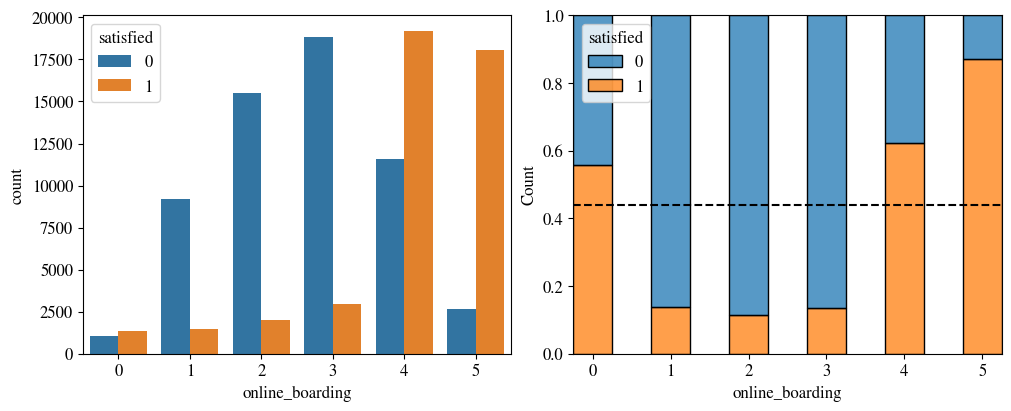

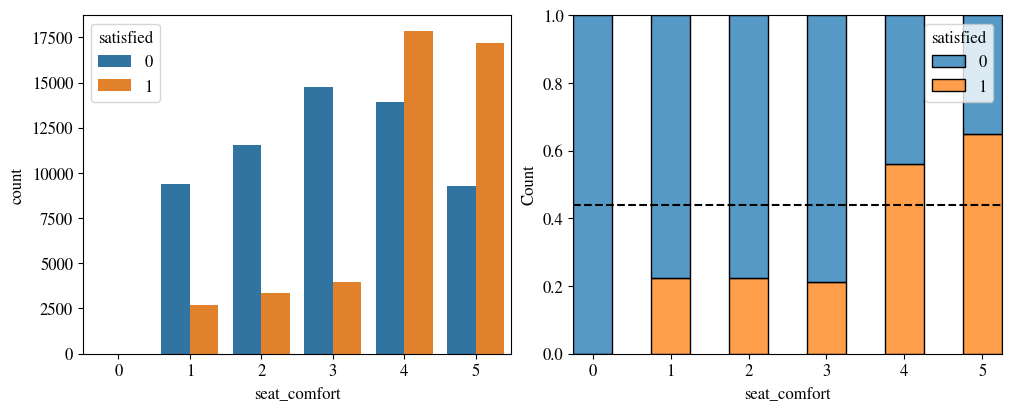

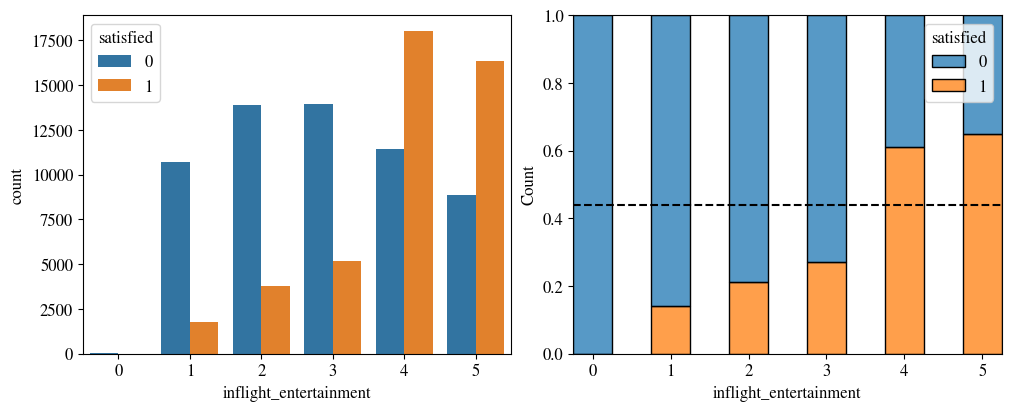

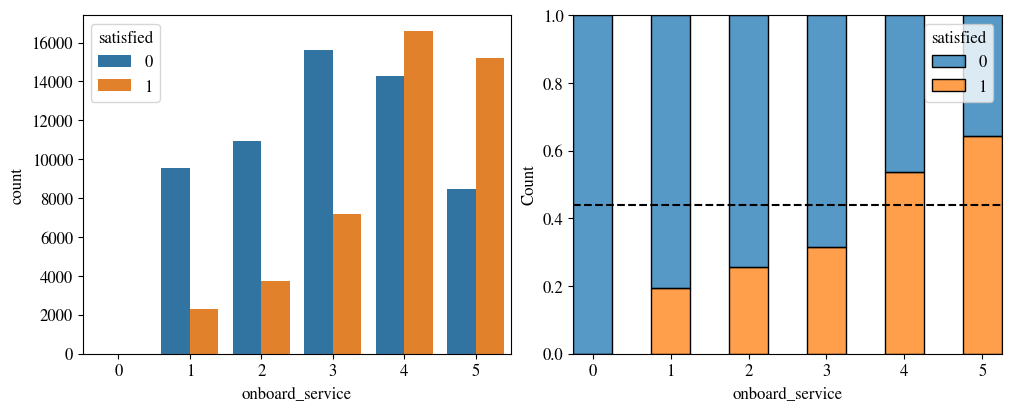

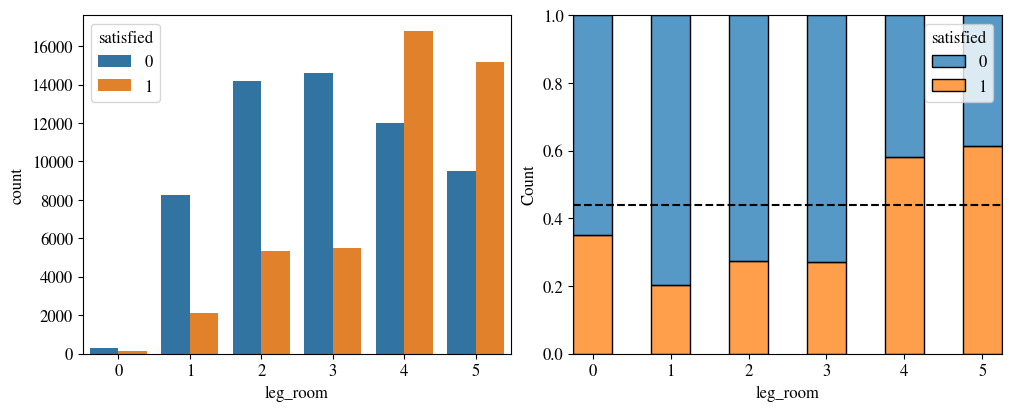

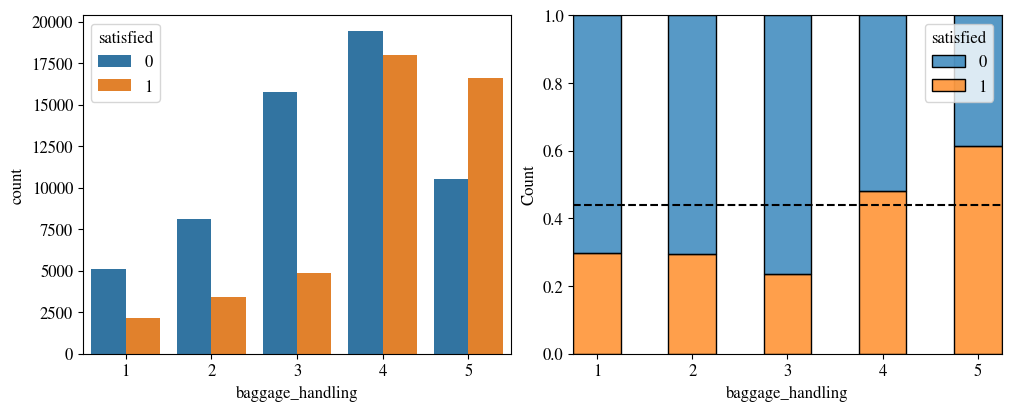

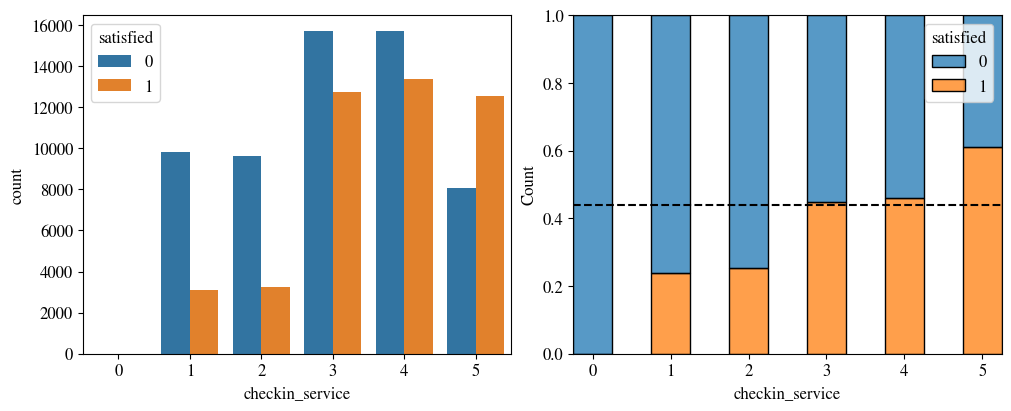

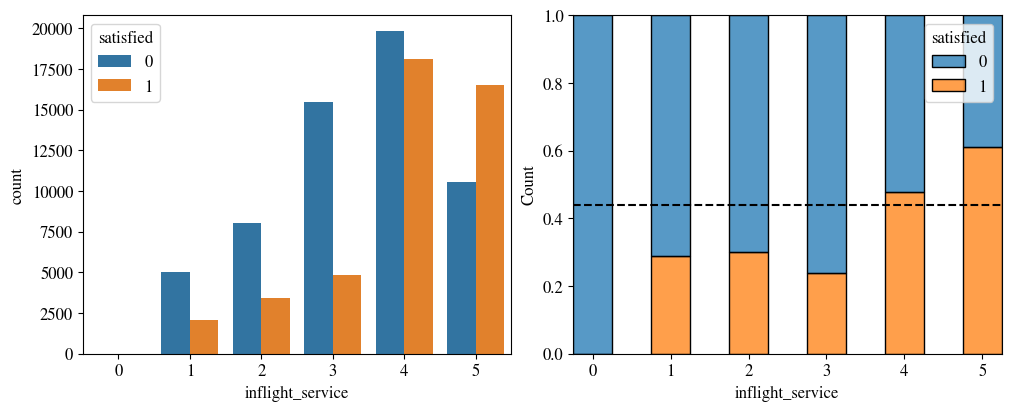

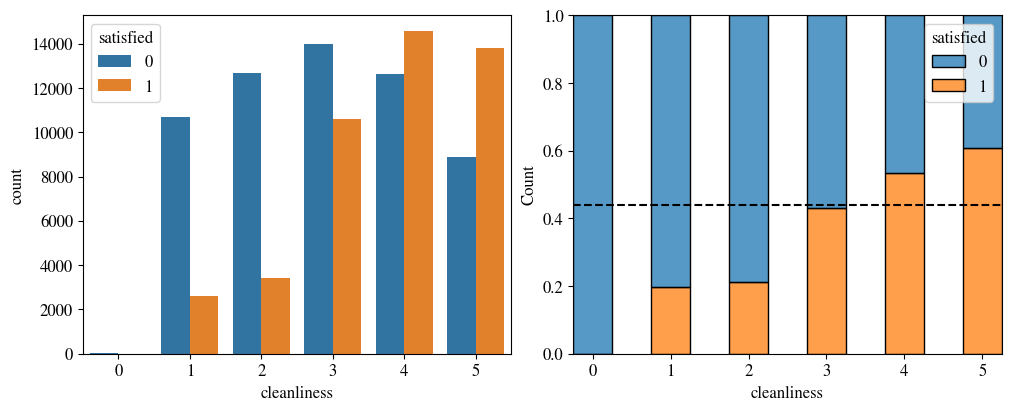

In [ ]:
for i, col in enumerate(model_config.RATED_COLS):
    fig, ax = plt.subplots(figsize=(10, 4), ncols=2, constrained_layout=True)
    sns.countplot(data=df, x=col, hue=model_config.TARGET, ax=ax[0])
    sns.histplot(
        data=df,
        x=col,
        multiple='fill',
        hue=model_config.TARGET,
        discrete=True,
        shrink=0.5,
        ax=ax[1],
    )
    ax[1].axhline(y=satisfied_frac, color='k', linestyle='--')
    plt.show()

Observations:

1. As would probably be expected, satisfaction rate tends to increase as ratings increase.

2. It's unclear what 0 means here. Given the generally low counts the way 0s are distributed, it seems that it may be "N/A" rather than a true 0 rating.

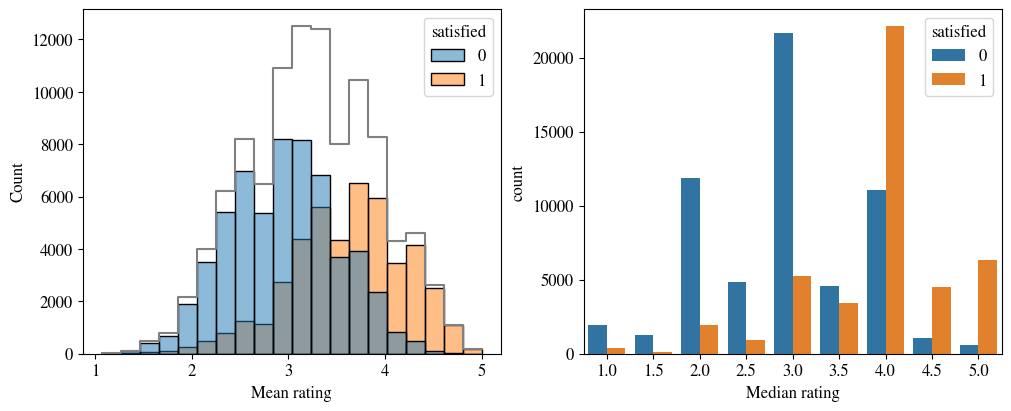

In [ ]:
mean_rating = df[model_config.RATED_COLS].mean(axis=1)
median_rating = df[model_config.RATED_COLS].median(axis=1)

fig, ax = plt.subplots(figsize=(10, 4), ncols=2, constrained_layout=True)
sns.histplot(x=mean_rating, bins=20, ax=ax[0], element='step', fill=False, color='gray')
sns.histplot(x=mean_rating, bins=20, hue=satisfied, ax=ax[0])
sns.countplot(x=median_rating, hue=satisfied, ax=ax[1])
ax[0].set(xlabel='Mean rating')
ax[1].set(xlabel='Median rating')
plt.show()

Passengers who were satisfied with their flights generally gave higher ratings.

### Categorical Features

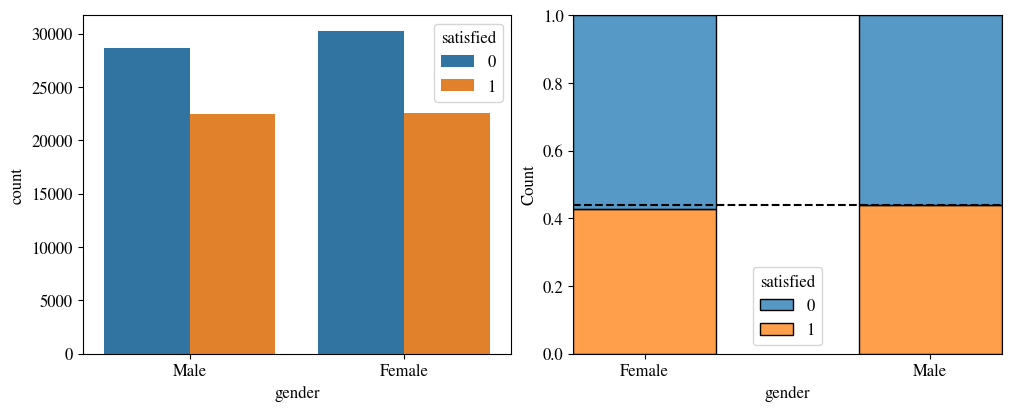

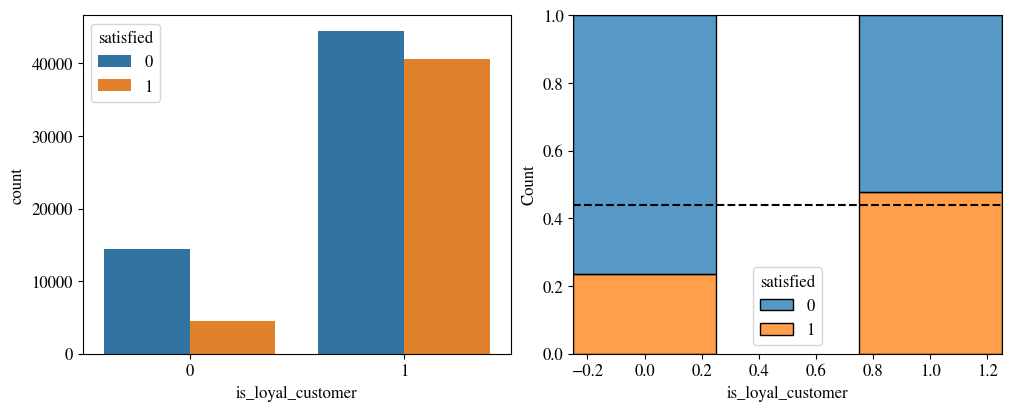

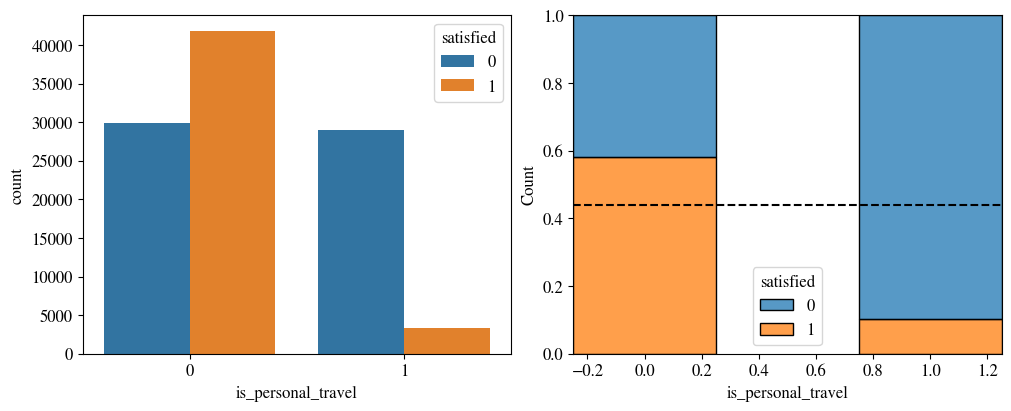

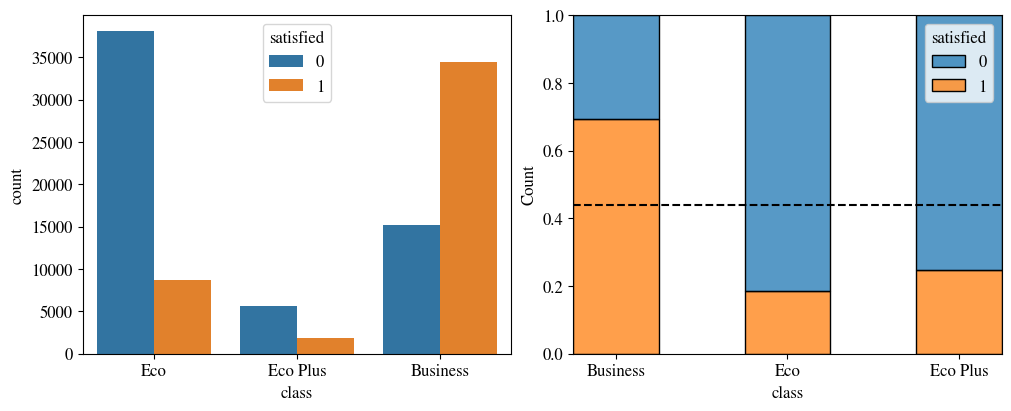

In [ ]:
for col in model_config.CATEGORICAL_COLS:
    fig, ax = plt.subplots(figsize=(10, 4), ncols=2, constrained_layout=True)
    sns.countplot(data=data, x=col, hue=model_config.TARGET, ax=ax[0])
    sns.histplot(
        data=df,
        x=col,
        multiple='fill',
        hue=model_config.TARGET,
        discrete=True,
        shrink=0.5,
        ax=ax[1],
    )
    ax[1].axhline(y=satisfied_frac, color='k', linestyle='--')
    plt.show()

Observations:

1. There is a very minimal difference between the male and female satisfaction rates. Rather than relying on this information, particularly as a binary variable, we'll drop this category.

2. Loyal customers tend to have a higher satisfaction rate than disloyal customers.

3. Passengers traveling for business reasons have a significantly higher satisfaction rate than passengers traveling for personal reasons. Passengers traveling for business reasons may have a higher rate of being in business class, or may just be more accustomed to flying.

4. Passengers in business class have a high satisfaction rate compared to passengers in economy or economy plus. Economy plus passengers are only slightly more satisfied than those in economy.

### Correlation Matrix

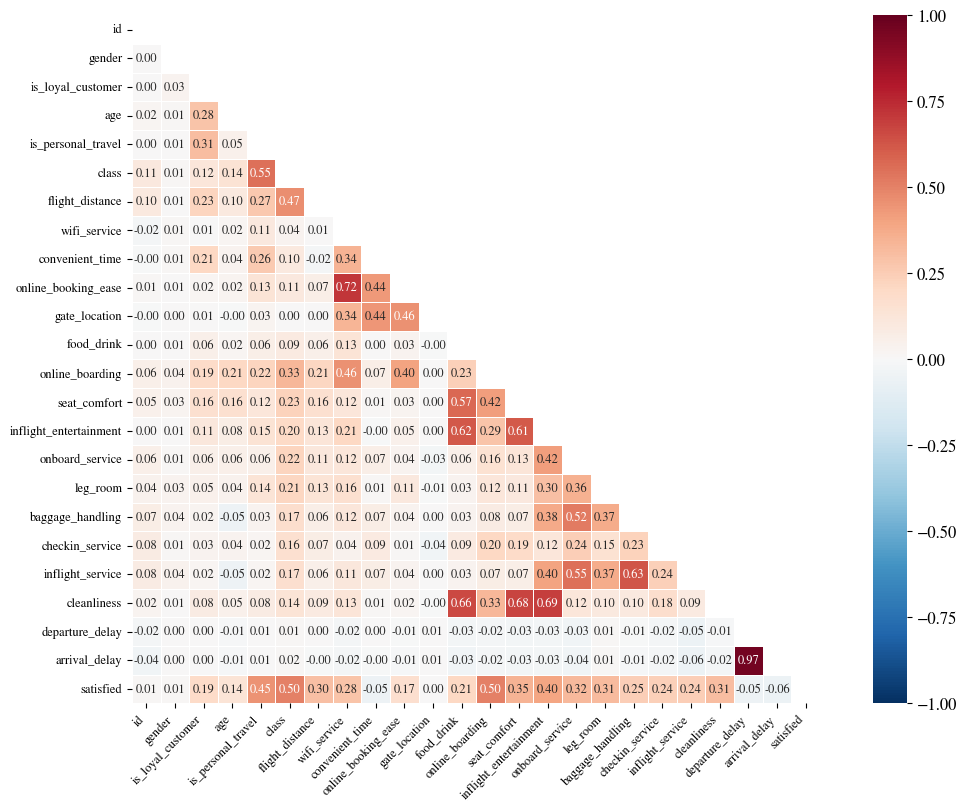

In [22]:
results = associations(df, compute_only=True)
corr_matrix = results['corr']
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 9},
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)

plt.show()

Observations:

1. There is a very strong correlation between departure and arrival delays. If these features are used, we probably only need one of them.

2. There's a fairly strong correlation between ease of online booking and inflight wifi service. These don't initially seem directly related, but it may signal the tech-savviness of customers. Less tech-savvy customers may have troubles with booking tickets online and figuring out how to use inflight wifi, giving them an overall lower satisfaction.

3. There is some correlation among cleanliness, seat comfort, food and drink, and inflight entertainment. This might signal the overall general comfort of customers in the physical airplane space.

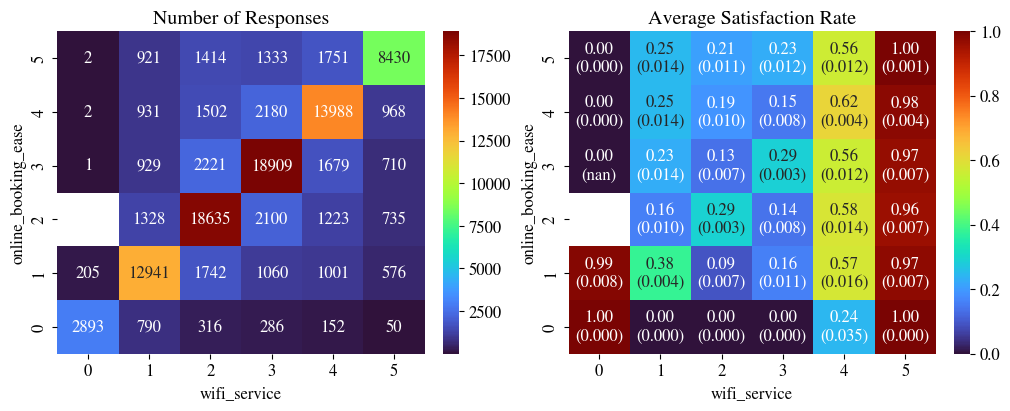

In [23]:
pivot_count = df.pivot_table(
    index='online_booking_ease',
    columns='wifi_service',
    values='satisfied',
    aggfunc='count',
)

stats = df.groupby(['online_booking_ease', 'wifi_service'])['satisfied'].agg(
    ['mean', 'sem']
)
pivot_mean = stats['mean'].unstack()
pivot_std = stats['sem'].unstack()

annot_labels = (
    pivot_mean.map(lambda x: f'{x:.2f}')
    + '\n('
    + pivot_std.map(lambda x: f'{x:.3f}')
    + ')'
)

fig, ax = plt.subplots(figsize=(10, 4), ncols=2, constrained_layout=True)

sns.heatmap(pivot_count, annot=True, fmt='g', cmap='turbo', ax=ax[0])
ax[0].set_title('Number of Responses')
ax[0].invert_yaxis()

sns.heatmap(pivot_mean, annot=annot_labels, fmt='', cmap='turbo', ax=ax[1])
ax[1].set_title('Average Satisfaction Rate')
ax[1].invert_yaxis()

plt.show()

Observations:

1. Even though ease of online booking and inflight wifi service don't seem to be related, customers tend to rate them the same way (most counts on the diagonal of the left subplot).

2. Inflight wifi service rating has a strong effect on satisfaction rate. When it's rated a 5, satisfaction is nearly perfect regardless of the online booking rating. When wifi rating is a 4, satisfaction is almost always ~0.6 regardless of online booking rating. When wifi rating is below a 4, there is another big dropoff in satisfaction rating.

3. Given the two observations above, it seems that the ease of online booking rating is being affected by the inflight wifi service rating. When wifi service is rated high, customers are satisfied and rate their ease of online booking high as well. When wifi service is rated low, customers are not satisfied and ease of online booking is also rated low. This could still be influenced by the customers' tech savviness, but it could also be customers' prior feelings (their experience when booking) being superceded by their more recent feelings (their experience with the wifi on the flight).

### Type of Travel vs Class

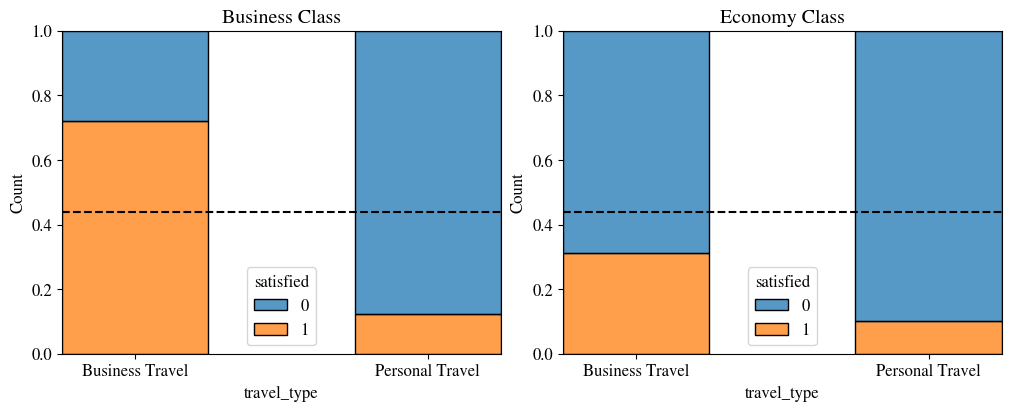

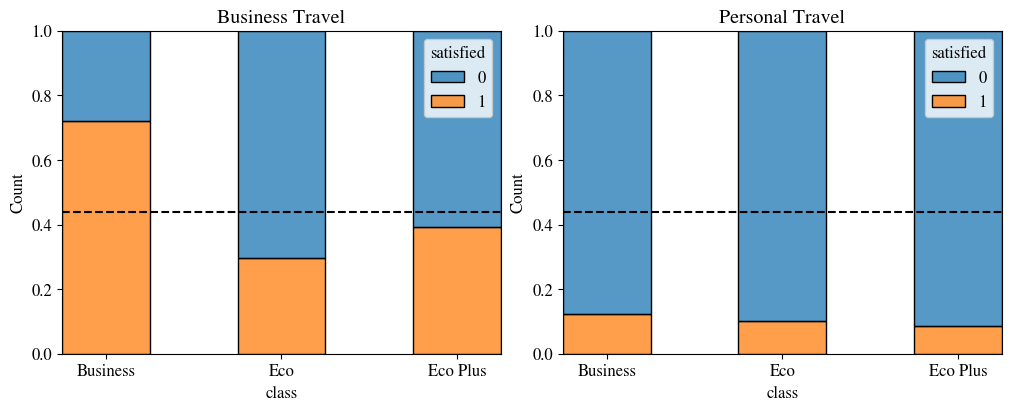

In [ ]:
graph_set1 = (
    'class',
    'Business',
    'travel_type',
    'Business Class',
    'Economy Class',
)
graph_set2 = (
    'travel_type',
    'Business Travel',
    'class',
    'Business Travel',
    'Personal Travel',
)

df['travel_type'] = np.where(
    df['is_personal_travel'] == 1, 'Personal Travel', 'Business Travel'
)

for gset in [graph_set1, graph_set2]:
    group_col, group_cat, divide_col, title1, title2 = gset
    fig, ax = plt.subplots(figsize=(10, 4), ncols=2, constrained_layout=True)
    sns.histplot(
        data=df[df[group_col] == group_cat],
        x=divide_col,
        multiple='fill',
        hue=model_config.TARGET,
        discrete=True,
        shrink=0.5,
        ax=ax[0],
    )
    sns.histplot(
        data=df[df[group_col] != group_cat],
        x=divide_col,
        multiple='fill',
        hue=model_config.TARGET,
        discrete=True,
        shrink=0.5,
        ax=ax[1],
    )
    ax[0].axhline(y=satisfied_frac, color='k', linestyle='--')
    ax[1].axhline(y=satisfied_frac, color='k', linestyle='--')
    ax[0].set_title(title1)
    ax[1].set_title(title2)
    plt.show()

Observations:

1. Type of travel matters a lot. Among passengers flying for personal reasons, satisfaction rates are always low and vary little across different ticket classes.

2. Among passengers who flew in economy class, those traveling for business reasons were generally more satisfied. In business class, the reason for travel makes a huge difference in satisfaction.